# 性能チューニング: プルーニング、射影、コミット粒度、キャッシュ

h5i-db はテーブルを、バージョン管理されたマニフェストの下の、書き換え不能で時刻順の Parquet
セグメントとして保存します。この構成が、何がクエリを速くし、何が静かに遅くするかを決めます。

1. **時間範囲のプルーニング**。マニフェストが各セグメントの時間範囲を記録しているので、
   時刻の述語は I/O が始まる前にセグメントを丸ごと読み飛ばします。
2. **列の射影**。Parquet は列指向です。触る列が少なければ、読むバイトも少なくなります。
3. **コミットの粒度**。コミットのたびにマニフェストと最低1つのセグメントが書かれます。
   小さなコミットが1,000回あれば、`compact()` するまで小さなファイルが1,000個です。
4. **キャッシュ**。データベースを開いた直後の最初のクエリは、以後のクエリが払わずに済む
   セグメントのフッタとメタデータの読み込みを払います。

約300万行のティックテーブルでこの4つを測り、最後に共有のリサーチマシンで行儀よくいるための
安全装置（`timeout`、`max_rows`、`memory_limit`）で締めます。絶対値はマシン依存です。教訓は
*比率*のほうにあります。

In [1]:
import time

import matplotlib.pyplot as plt
import pandas as pd

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_perf"), create=True)


def bench(fn, repeat=3):
    """Best-of-3 wall time - min filters out scheduler/GC noise."""
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return min(times)


timings_ms = {}  # collected for the chart at the end

## 1. データセット: 10日ぶんのティック、1日1コミット

約300万行を1日ずつ append します。h5i-db が期待するバッチ化のパターン（公表イベント1件につき
1コミット。1行ずつでも、一枚岩でもなく）です。10コミットなので、おおむね1日1セグメントになり、
これが以下の時刻の述語にプルーニングの余地を与えます。

In [2]:
trades = cu.make_trades(symbols=["AAPL", "MSFT", "NVDA"], days=10, trades_per_day=100_000, seed=42)
db.create_table("trades", trades.schema, time_column="ts", sort_key=["ts", "symbol"])

trades_df_ts = trades["ts"].to_pandas()
day_starts = trades_df_ts.dt.normalize().unique()
t0 = time.perf_counter()
for day in day_starts:
    day_end = day + pd.Timedelta(days=1)
    mask_lo = trades_df_ts.searchsorted(day)
    mask_hi = trades_df_ts.searchsorted(day_end)
    db.append("trades", trades.slice(mask_lo, mask_hi - mask_lo), note=f"day {day.date()}")
print(f"{len(trades):,} rows in {len(day_starts)} daily commits ({time.perf_counter() - t0:.1f}s)")

2,945,940 rows in 10 daily commits (1.3s)


## 2. 時間範囲のプルーニング: 10年ではなく1日をスキャンする

同じ形のクエリを2つの期間で。*全部*を実体化する場合と、10日のうち1日だけの場合です。1日の
スキャンが触るのは全行の約10%で、マニフェストのおかげで残り9つのセグメントは開かずに済みます。
2つの系統に注意してください。生の実体化（`SELECT *`）はプルーニングの効果が全開で出ます。
一方 `GROUP BY` の集約は行あたりの計算が軽いので、実時間の改善は小さくなります。プルーニングが
節約するのは I/O であって、ハッシュテーブルの仕事ではありません。

In [3]:
lo = int(pd.Timestamp("2026-06-05", tz="UTC").value // 1000)
hi = int(pd.Timestamp("2026-06-06", tz="UTC").value // 1000)
day_pred = f"ts >= to_timestamp_micros({lo}) AND ts < to_timestamp_micros({hi})"
agg = "SELECT symbol, count(*) AS n, vwap(price, size) AS vw FROM trades {} GROUP BY symbol"

timings_ms["SELECT * (10 days)"] = 1e3 * bench(lambda: db.sql("SELECT * FROM trades").to_arrow())
timings_ms["SELECT * (1 day)"] = 1e3 * bench(lambda: db.sql(f"SELECT * FROM trades WHERE {day_pred}").to_arrow())
timings_ms["agg (10 days)"] = 1e3 * bench(lambda: db.sql(agg.format("")).to_arrow())
timings_ms["agg (1 day)"] = 1e3 * bench(lambda: db.sql(agg.format(f"WHERE {day_pred}")).to_arrow())

print(f"materialize: {timings_ms['SELECT * (10 days)']:.0f} ms full -> "
      f"{timings_ms['SELECT * (1 day)']:.0f} ms one day "
      f"({timings_ms['SELECT * (10 days)'] / timings_ms['SELECT * (1 day)']:.1f}x)")
print(f"aggregate:   {timings_ms['agg (10 days)']:.1f} ms full -> "
      f"{timings_ms['agg (1 day)']:.1f} ms one day "
      f"({timings_ms['agg (10 days)'] / timings_ms['agg (1 day)']:.1f}x)")

materialize: 189 ms full -> 19 ms one day (10.1x)
aggregate:   14.8 ms full -> 15.6 ms one day (1.0x)


## 3. 射影: 列に名前を付ける

6列のティックテーブルへの `SELECT *` は、symbol／exchange／side の文字列をすべての演算子に
引きずり回します。必要な2列を名指しすれば、その Parquet の列チャンクだけを読みます。列指向の
古典的な勝ち筋であり、`SELECT *` が探索用であって定期ジョブ向けではない理由でもあります。

In [4]:
timings_ms["SELECT ts, price"] = 1e3 * bench(lambda: db.sql("SELECT ts, price FROM trades").to_arrow())
print(f"SELECT *:         {timings_ms['SELECT * (10 days)']:.0f} ms")
print(f"SELECT ts, price: {timings_ms['SELECT ts, price']:.0f} ms "
      f"({timings_ms['SELECT * (10 days)'] / timings_ms['SELECT ts, price']:.1f}x)")

SELECT *:         189 ms
SELECT ts, price: 38 ms (5.0x)


## 4. コミットの粒度と、対処としての `compact()`

どのコミットも耐久性を持ちます。マニフェストの書き込み、fsync、新しいセグメントファイル。
1日ぶんのティックを300回のマイクロバッチでコミットすれば、取り込み時にその代金を300回払い、
*なおかつ*以後のクエリが毎回開くことになる小さなセグメントを300個残します。`compact()` は
それを1つのセグメントに書き直して新しいバージョンとしてコミットします。履歴は無傷で、古い
バージョンも読めるままです。

1日ぶんのティック（約30万行）を、両方のやり方で取り込んでみます。

In [5]:
day1 = cu.make_trades(symbols=["AAPL", "MSFT", "NVDA"], days=1, trades_per_day=100_000, seed=43)

db.create_table("t_one", day1.schema, time_column="ts", sort_key=["ts", "symbol"])
t0 = time.perf_counter()
db.append("t_one", day1)
ingest_one = time.perf_counter() - t0

db.create_table("t_many", day1.schema, time_column="ts", sort_key=["ts", "symbol"])
n, k = len(day1), 300
chunk = n // k
t0 = time.perf_counter()
for i in range(k):
    db.append("t_many", day1.slice(i * chunk, chunk if i < k - 1 else n - (k - 1) * chunk))
ingest_many = time.perf_counter() - t0

print(f"ingest {n:,} rows: 1 commit {ingest_one:.2f}s vs {k} commits {ingest_many:.2f}s "
      f"({ingest_many / ingest_one:.0f}x slower)")

ingest 298,885 rows: 1 commit 0.12s vs 300 commits 4.69s (40x slower)


In [6]:
agg1 = "SELECT symbol, count(*) AS n, vwap(price, size) AS vw FROM {} GROUP BY symbol"
timings_ms["agg, 1 segment"] = 1e3 * bench(lambda: db.sql(agg1.format("t_one")).to_arrow())
timings_ms["agg, 300 segments"] = 1e3 * bench(lambda: db.sql(agg1.format("t_many")).to_arrow())

t0 = time.perf_counter()
c = db.compact("t_many")
compact_s = time.perf_counter() - t0
timings_ms["agg, compacted"] = 1e3 * bench(lambda: db.sql(agg1.format("t_many")).to_arrow())

print(f"aggregation: {timings_ms['agg, 300 segments']:.1f} ms on 300 segments, "
      f"{timings_ms['agg, 1 segment']:.1f} ms on 1 segment")
print(f"compact() took {compact_s:.2f}s -> segments_total={c['segments_total']}, "
      f"now {timings_ms['agg, compacted']:.1f} ms "
      f"({timings_ms['agg, 300 segments'] / timings_ms['agg, compacted']:.1f}x recovered)")

aggregation: 41.9 ms on 300 segments, 11.0 ms on 1 segment
compact() took 0.70s -> segments_total=1, now 8.0 ms (5.2x recovered)


## 5. コールドとウォーム: 最初のクエリがメタデータの代金を払う

データベースを開き直して、同じ集約を2回走らせます。1回目はセグメントのフッタを読み、メタ
データのキャッシュを作ります。2回目以降はそれを飛ばします。ローカルの NVMe なら差はささやかです。
NFS やオブジェクトストレージ越しなら、長生きする読み手を残しておく価値を生む差になります。

In [7]:
db.close()
db = h5i_db.Database(cu.db_path("prod_perf"))  # fresh handle, cold caches

t0 = time.perf_counter()
db.sql(agg.format("")).to_arrow()
timings_ms["agg cold (1st run)"] = 1e3 * (time.perf_counter() - t0)
timings_ms["agg warm (best of 3)"] = 1e3 * bench(lambda: db.sql(agg.format("")).to_arrow())

print(f"cold: {timings_ms['agg cold (1st run)']:.1f} ms, warm: {timings_ms['agg warm (best of 3)']:.1f} ms "
      f"({timings_ms['agg cold (1st run)'] / timings_ms['agg warm (best of 3)']:.1f}x)")

cold: 15.3 ms, warm: 17.6 ms (0.9x)


## 6. 集計表

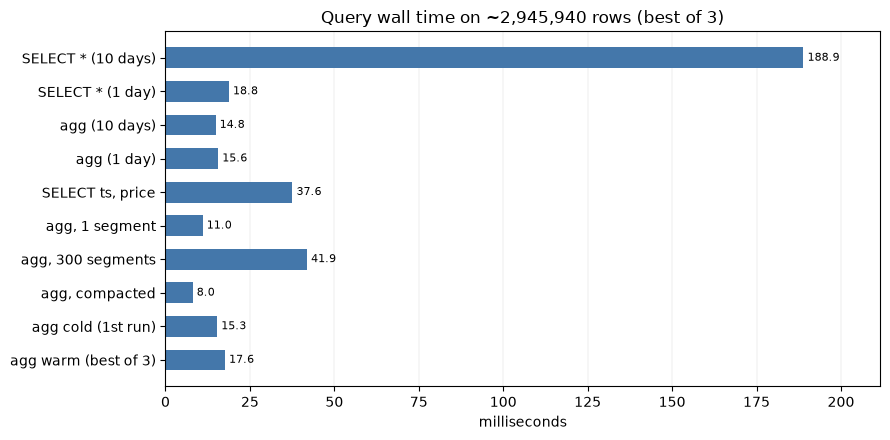

In [8]:
labels = list(timings_ms)[::-1]
values = [timings_ms[k] for k in labels]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(labels, values, height=0.62, color="#4477aa")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
ax.set_title(f"Query wall time on ~{len(trades):,} rows (best of 3)")
ax.set_xlabel("milliseconds")
ax.margins(x=0.12)
ax.grid(axis="x", lw=0.3, alpha=0.5)
ax.set_axisbelow(True)
fig.tight_layout()

## 7. 資源の安全装置: 本番での作法

共有マシン（あるいは SQL を叩けるエージェント）には、マシンを食い尽くすのではなく速く大きな
声で失敗するクエリが要ります。`db.sql` はどれも `timeout=` 秒、`max_rows=`、`memory_limit=`
バイトを受け取り、違反すると型の付いた例外（`TimeoutError`、`LimitError`）を、警報を出せる
`.code` 付きで上げます。`except Exception` で握りつぶさず、これらを捕まえてください。

In [9]:
try:
    db.sql("SELECT * FROM trades", max_rows=100_000)
except h5i_db.LimitError as e:
    print(f"max_rows    -> LimitError   code={e.code} hint={e.hint}")

try:
    db.sql("SELECT * FROM trades", timeout=0.001)
except h5i_db.TimeoutError as e:
    print(f"timeout     -> TimeoutError code={e.code}")

try:
    db.sql(agg.format(""), memory_limit=100_000)  # 100 kB budget: not enough
except h5i_db.LimitError as e:
    print(f"memory_limit-> LimitError   code={e.code}")

max_rows    -> LimitError   code=limit_exceeded hint=None
timeout     -> TimeoutError code=timeout
memory_limit-> LimitError   code=limit_exceeded


## 8. エンジンの代金 — 正直な数字

設計文書によれば、h5i-db の汎用スキャン経路は、**同じ Parquet ファイルを素の DataFusion で
クエリする場合と比べておよそ20%のオーバーヘッド**を負います。バージョンの解決、マニフェストの
管理、プルーニングの仕掛けの代金です。その代わりにタイムトラベル、アトミックなコミット、
時系列の演算子が手に入ります。一度きりの大量スキャンが本当にレイテンシ勝負なら、テーブルの
セグメントファイルに別の Parquet リーダーを向ければ済みます。本番の数字を実際に動かす
チューニングのつまみを、手を伸ばすべき順に挙げます。

1. 自然な窓を持つクエリには、必ず時刻の述語を付ける
2. 列に名前を付ける
3. append をまとめる（フィードのバッチごとに1コミット）。バースト的な取り込みのあとは
   `compact()` する
4. 読み手のプロセスを生かしておいて、キャッシュを温かく保つ
5. ユーザーやエージェントが生成するものには `timeout`／`max_rows`／`memory_limit` を設定する

## まとめ

- 時刻の述語は、このシステムでいちばん安い高速化です。マニフェストが I/O の前にセグメントを
  丸ごと落とします。ここでは実体化するスキャンで約8倍でした（集約の伸びは小さくなります。
  コストが I/O ではなくハッシュの仕事だからです）。
- 幅のあるティックテーブルでは射影が効きます。300万行に対して、2列は `SELECT *` の約3倍の
  速さでした。
- コミットの粒度は本物のつまみです。300回のマイクロコミットは、まとめた1コミットに比べて
  取り込みを約60倍、クエリを約3〜4倍遅くしました。`compact()` は1秒足らずでクエリ時間を
  取り戻します。
- コールドオープンの代金はプロセスごとに1回だけです。長生きする読み手が償却してくれます。
- 安全装置（`timeout`、`max_rows`、`memory_limit`）は資源の暴発を、型が付いて捕捉できる
  エラーに変えます。共有マシンとエージェントのアクセスには必須です。

In [10]:
db.close()